In [13]:
import numpy as np
from sklearn.decomposition import PCA
from pyod.models.knn import KNN
import pandas as pd
from scipy.stats import mode
from sklearn.metrics import precision_score, recall_score, roc_auc_score

def calculate_knn_outlier_scores(data, n_samples, sample_fraction, n_components, n_neighbors, contamination):
    """
    Performs outlier detection using PCA and KNN with voting mechanism, returning final labels and scores.
    
    Parameters:
        data (numpy.ndarray): The input dataset.
        n_samples (int): Number of random samples to generate.
        sample_fraction (float): Fraction of the data to include in each sample.
        n_components (int): Number of PCA components.
        n_neighbors (int): Number of neighbors for KNN.
        contamination (float): Contamination level for KNN.
    
    Returns:
        numpy.ndarray: A binary array indicating whether each data point is an outlier (1) or not (0).
        numpy.ndarray: Average outlier scores for each data point.
    """
    n_data_points = data.shape[0]
    sample_size = int(n_data_points * sample_fraction)
    all_labels = np.zeros((n_samples, n_data_points), dtype=int)
    all_scores = np.zeros((n_samples, n_data_points), dtype=float)
    
    for i in range(n_samples):
        # Step 1: Random sampling
        sampled_indices = np.random.choice(n_data_points, sample_size, replace=False)
        sampled_data = data[sampled_indices]
        
        # Step 2: PCA transformation
        pca = PCA(n_components=n_components)
        reduced_data = pca.fit_transform(sampled_data)
        
        # Step 3: KNN outlier detection
        knn = KNN(n_neighbors=n_neighbors, contamination=contamination)
        knn.fit(reduced_data)
        
        # Assign outlier labels and scores to the full dataset
        full_reduced_data = pca.transform(data)
        labels = knn.predict(full_reduced_data)
        scores = knn.decision_function(full_reduced_data)  # Outlier scores
        
        all_labels[i] = labels
        all_scores[i] = scores
    
    # Step 4: Voting mechanism
    final_labels = mode(all_labels, axis=0)[0].flatten()
    average_scores = all_scores.mean(axis=0)
    
    return final_labels, average_scores

def evaluate_knn_outlier_detection(y_true, y_pred, y_scores):
    """
    Evaluates outlier detection performance using Precision, Recall, and AUC.
    
    Parameters:
        y_true (numpy.ndarray): Ground truth (0 for inliers, 1 for outliers).
        y_pred (numpy.ndarray): Predicted labels (0 for inliers, 1 for outliers).
        y_scores (numpy.ndarray): Outlier scores for each data point.
    
    Returns:
        Precision, Recall, and AUC scores.
    """
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_scores)
    return  precision, recall, auc



Total number of samples: 6801
Testing K values: [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69, 71, 73, 75, 77, 79, 81]


C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Best Hyperparameters (from Cross-Validation):
n_components (PCA): 2
k (Number of Neighbors): 17
Average AUC (Cross-Validation): 0.5373065488594371


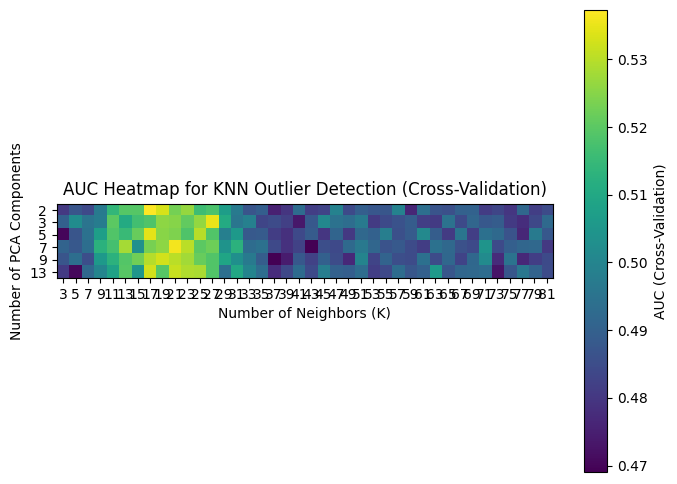

In [12]:
# KNN
# dataset: Annthyroid_norm_02_v01.csv
# stratified kfold cv
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Annthyroid\\Annthyroid_norm_02_v01.csv"
# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate features (all columns except the last) and labels (last column)
data = df.iloc[:, :-1].values
labels = df.iloc[:, -1].values

# Dynamically calculate odd K values based on the dataset size
N_samples = len(data)  # Total number of samples
max_k = int(math.sqrt(N_samples))  # sqrt(N) for the dataset
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Total number of samples:", N_samples)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13]  # Number of PCA components

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold stratified cross-validation
cv_results = []  # To store cross-validation results

# Perform stratified cross-validation
for n_components in n_components_values:
    for k in k_values:
        fold_aucs = []  # Store AUCs for each fold
        for train_idx, val_idx in skf.split(data, labels):
            # Split data into training and validation folds
            X_train_fold, X_val_fold = data[train_idx], data[val_idx]
            y_train_fold, y_val_fold = labels[train_idx], labels[val_idx]
            
            # Calculate KNN outlier scores on the training fold
            _, outlier_scores_fold = calculate_knn_outlier_scores(
                X_train_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation fold
            _, val_outlier_scores_fold = calculate_knn_outlier_scores(
                X_val_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Compute the AUC for this fold
            _, _, auc_fold = evaluate_knn_outlier_detection(y_val_fold, _, val_outlier_scores_fold)
            fold_aucs.append(auc_fold)
        
        # Store the average AUC for this hyperparameter combination
        avg_auc = np.mean(fold_aucs)
        cv_results.append((n_components, k, avg_auc))

# Convert CV results to a structured array for analysis
cv_results = np.array(cv_results, dtype=[('n_components', int), ('k', int), ('auc', float)])

# Find the best parameters based on the maximum average AUC
best_index = np.argmax(cv_results['auc'])
best_n_components = cv_results['n_components'][best_index]
best_k = cv_results['k'][best_index]
best_auc = cv_results['auc'][best_index]

print(f"Best Hyperparameters (from Cross-Validation):")
print(f"n_components (PCA): {best_n_components}")
print(f"k (Number of Neighbors): {best_k}")
print(f"Average AUC (Cross-Validation): {best_auc}")

# Visualize the cross-validation results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        matching_auc = cv_results[(cv_results['n_components'] == n_components) & 
                                  (cv_results['k'] == k)]['auc']
        auc_matrix[i, j] = matching_auc[0] if len(matching_auc) > 0 else 0

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC (Cross-Validation)')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection (Cross-Validation)')
plt.show()


In [16]:
# KNN
# dataset: Arrhythmia_withoutdupl_norm_02_v01.csv
# stratified kfold cv
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Arrhythmia\\Arrhythmia_withoutdupl_norm_02_v01.csv"
# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate features (all columns except the last) and labels (last column)
data = df.iloc[:, :-1].values
labels = df.iloc[:, -1].values

# Dynamically calculate odd K values based on the dataset size
N_samples = len(data)  # Total number of samples
max_k = int(math.sqrt(N_samples))  # sqrt(N) for the dataset
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Total number of samples:", N_samples)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13, 15, 25, 35]  # Number of PCA components

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold stratified cross-validation
cv_results = []  # To store cross-validation results

# Perform stratified cross-validation
for n_components in n_components_values:
    for k in k_values:
        fold_aucs = []  # Store AUCs for each fold
        for train_idx, val_idx in skf.split(data, labels):
            # Split data into training and validation folds
            X_train_fold, X_val_fold = data[train_idx], data[val_idx]
            y_train_fold, y_val_fold = labels[train_idx], labels[val_idx]
            
            # Calculate KNN outlier scores on the training fold
            _, outlier_scores_fold = calculate_knn_outlier_scores(
                X_train_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation fold
            _, val_outlier_scores_fold = calculate_knn_outlier_scores(
                X_val_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Compute the AUC for this fold
            _, _, auc_fold = evaluate_knn_outlier_detection(y_val_fold, _, val_outlier_scores_fold)
            fold_aucs.append(auc_fold)
        
        # Store the average AUC for this hyperparameter combination
        avg_auc = np.mean(fold_aucs)
        cv_results.append((n_components, k, avg_auc))

# Convert CV results to a structured array for analysis
cv_results = np.array(cv_results, dtype=[('n_components', int), ('k', int), ('auc', float)])

# Find the best parameters based on the maximum average AUC
best_index = np.argmax(cv_results['auc'])
best_n_components = cv_results['n_components'][best_index]
best_k = cv_results['k'][best_index]
best_auc = cv_results['auc'][best_index]

print(f"Best Hyperparameters (from Cross-Validation):")
print(f"n_components (PCA): {best_n_components}")
print(f"k (Number of Neighbors): {best_k}")
print(f"Average AUC (Cross-Validation): {best_auc}")

# Visualize the cross-validation results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        matching_auc = cv_results[(cv_results['n_components'] == n_components) & 
                                  (cv_results['k'] == k)]['auc']
        auc_matrix[i, j] = matching_auc[0] if len(matching_auc) > 0 else 0

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC (Cross-Validation)')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection (Cross-Validation)')
plt.show()


Total number of samples: 247
Testing K values: [3, 5, 7, 9, 11, 13, 15]


c:\Users\asus\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behav

ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.

Total number of samples: 1687
Testing K values: [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41]


C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Best Hyperparameters (from Cross-Validation):
n_components (PCA): 9
k (Number of Neighbors): 5
Average AUC (Cross-Validation): 0.8837289598618903


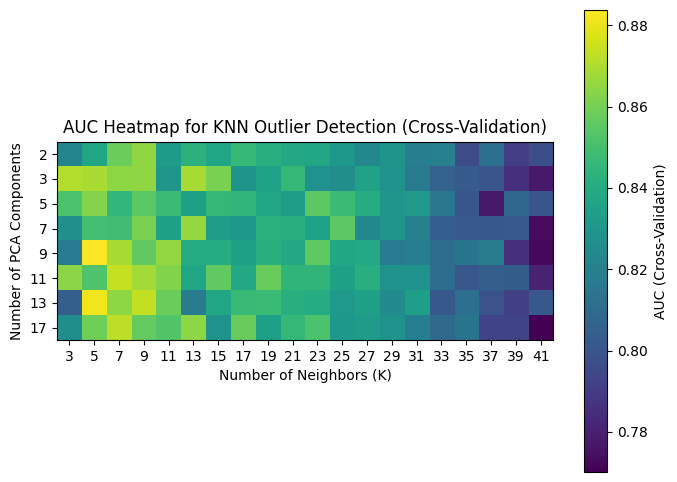

In [15]:
# KNN
# dataset: Cardiotocography_norm_02_v01.csv
# stratified kfold cv
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Cardiotocography\\Cardiotocography_norm_02_v01.csv"
# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate features (all columns except the last) and labels (last column)
data = df.iloc[:, :-1].values
labels = df.iloc[:, -1].values

# Dynamically calculate odd K values based on the dataset size
N_samples = len(data)  # Total number of samples
max_k = int(math.sqrt(N_samples))  # sqrt(N) for the dataset
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Total number of samples:", N_samples)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 11, 13, 17]  # Number of PCA components

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold stratified cross-validation
cv_results = []  # To store cross-validation results

# Perform stratified cross-validation
for n_components in n_components_values:
    for k in k_values:
        fold_aucs = []  # Store AUCs for each fold
        for train_idx, val_idx in skf.split(data, labels):
            # Split data into training and validation folds
            X_train_fold, X_val_fold = data[train_idx], data[val_idx]
            y_train_fold, y_val_fold = labels[train_idx], labels[val_idx]
            
            # Calculate KNN outlier scores on the training fold
            _, outlier_scores_fold = calculate_knn_outlier_scores(
                X_train_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation fold
            _, val_outlier_scores_fold = calculate_knn_outlier_scores(
                X_val_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Compute the AUC for this fold
            _, _, auc_fold = evaluate_knn_outlier_detection(y_val_fold, _, val_outlier_scores_fold)
            fold_aucs.append(auc_fold)
        
        # Store the average AUC for this hyperparameter combination
        avg_auc = np.mean(fold_aucs)
        cv_results.append((n_components, k, avg_auc))

# Convert CV results to a structured array for analysis
cv_results = np.array(cv_results, dtype=[('n_components', int), ('k', int), ('auc', float)])

# Find the best parameters based on the maximum average AUC
best_index = np.argmax(cv_results['auc'])
best_n_components = cv_results['n_components'][best_index]
best_k = cv_results['k'][best_index]
best_auc = cv_results['auc'][best_index]

print(f"Best Hyperparameters (from Cross-Validation):")
print(f"n_components (PCA): {best_n_components}")
print(f"k (Number of Neighbors): {best_k}")
print(f"Average AUC (Cross-Validation): {best_auc}")

# Visualize the cross-validation results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        matching_auc = cv_results[(cv_results['n_components'] == n_components) & 
                                  (cv_results['k'] == k)]['auc']
        auc_matrix[i, j] = matching_auc[0] if len(matching_auc) > 0 else 0

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC (Cross-Validation)')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection (Cross-Validation)')
plt.show()


In [17]:
# KNN
# dataset: HeartDisease_withoutdupl_norm_02_v01.csv
# stratified kfold cv
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# File path to the data
file_path = "G:\\Nazanin\\B project\\code\\dataset\\HeartDisease\\HeartDisease_withoutdupl_norm_02_v01.csv"
# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate features (all columns except the last) and labels (last column)
data = df.iloc[:, :-1].values
labels = df.iloc[:, -1].values

# Dynamically calculate odd K values based on the dataset size
N_samples = len(data)  # Total number of samples
max_k = int(math.sqrt(N_samples))  # sqrt(N) for the dataset
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Total number of samples:", N_samples)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 11]  # Number of PCA components

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold stratified cross-validation
cv_results = []  # To store cross-validation results

# Perform stratified cross-validation
for n_components in n_components_values:
    for k in k_values:
        fold_aucs = []  # Store AUCs for each fold
        for train_idx, val_idx in skf.split(data, labels):
            # Split data into training and validation folds
            X_train_fold, X_val_fold = data[train_idx], data[val_idx]
            y_train_fold, y_val_fold = labels[train_idx], labels[val_idx]
            
            # Calculate KNN outlier scores on the training fold
            _, outlier_scores_fold = calculate_knn_outlier_scores(
                X_train_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation fold
            _, val_outlier_scores_fold = calculate_knn_outlier_scores(
                X_val_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Compute the AUC for this fold
            _, _, auc_fold = evaluate_knn_outlier_detection(y_val_fold, _, val_outlier_scores_fold)
            fold_aucs.append(auc_fold)
        
        # Store the average AUC for this hyperparameter combination
        avg_auc = np.mean(fold_aucs)
        cv_results.append((n_components, k, avg_auc))

# Convert CV results to a structured array for analysis
cv_results = np.array(cv_results, dtype=[('n_components', int), ('k', int), ('auc', float)])

# Find the best parameters based on the maximum average AUC
best_index = np.argmax(cv_results['auc'])
best_n_components = cv_results['n_components'][best_index]
best_k = cv_results['k'][best_index]
best_auc = cv_results['auc'][best_index]

print(f"Best Hyperparameters (from Cross-Validation):")
print(f"n_components (PCA): {best_n_components}")
print(f"k (Number of Neighbors): {best_k}")
print(f"Average AUC (Cross-Validation): {best_auc}")

# Visualize the cross-validation results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        matching_auc = cv_results[(cv_results['n_components'] == n_components) & 
                                  (cv_results['k'] == k)]['auc']
        auc_matrix[i, j] = matching_auc[0] if len(matching_auc) > 0 else 0

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC (Cross-Validation)')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection (Cross-Validation)')
plt.show()


Total number of samples: 152
Testing K values: [3, 5, 7, 9, 11]


c:\Users\asus\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behav

ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.

In [18]:
# KNN
# dataset: Hepatitis_withoutdupl_norm_05_v01.csv
# stratified kfold cv
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# File path to the data
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Hepatitis\\Hepatitis_withoutdupl_norm_05_v01.csv"
# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate features (all columns except the last) and labels (last column)
data = df.iloc[:, :-1].values
labels = df.iloc[:, -1].values

# Dynamically calculate odd K values based on the dataset size
N_samples = len(data)  # Total number of samples
max_k = int(math.sqrt(N_samples))  # sqrt(N) for the dataset
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Total number of samples:", N_samples)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13, 15, 17]  # Number of PCA components

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold stratified cross-validation
cv_results = []  # To store cross-validation results

# Perform stratified cross-validation
for n_components in n_components_values:
    for k in k_values:
        fold_aucs = []  # Store AUCs for each fold
        for train_idx, val_idx in skf.split(data, labels):
            # Split data into training and validation folds
            X_train_fold, X_val_fold = data[train_idx], data[val_idx]
            y_train_fold, y_val_fold = labels[train_idx], labels[val_idx]
            
            # Calculate KNN outlier scores on the training fold
            _, outlier_scores_fold = calculate_knn_outlier_scores(
                X_train_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation fold
            _, val_outlier_scores_fold = calculate_knn_outlier_scores(
                X_val_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Compute the AUC for this fold
            _, _, auc_fold = evaluate_knn_outlier_detection(y_val_fold, _, val_outlier_scores_fold)
            fold_aucs.append(auc_fold)
        
        # Store the average AUC for this hyperparameter combination
        avg_auc = np.mean(fold_aucs)
        cv_results.append((n_components, k, avg_auc))

# Convert CV results to a structured array for analysis
cv_results = np.array(cv_results, dtype=[('n_components', int), ('k', int), ('auc', float)])

# Find the best parameters based on the maximum average AUC
best_index = np.argmax(cv_results['auc'])
best_n_components = cv_results['n_components'][best_index]
best_k = cv_results['k'][best_index]
best_auc = cv_results['auc'][best_index]

print(f"Best Hyperparameters (from Cross-Validation):")
print(f"n_components (PCA): {best_n_components}")
print(f"k (Number of Neighbors): {best_k}")
print(f"Average AUC (Cross-Validation): {best_auc}")

# Visualize the cross-validation results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        matching_auc = cv_results[(cv_results['n_components'] == n_components) & 
                                  (cv_results['k'] == k)]['auc']
        auc_matrix[i, j] = matching_auc[0] if len(matching_auc) > 0 else 0

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC (Cross-Validation)')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection (Cross-Validation)')
plt.show()


Total number of samples: 69
Testing K values: [3, 5, 7]


c:\Users\asus\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behav

ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.

In [19]:
# KNN
# dataset: Lymphography_withoutdupl_norm_1ofn.csv
# stratified kfold cv
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# File path to the data
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Lymphography\\Lymphography_withoutdupl_norm_1ofn.csv"
# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate features (all columns except the last) and labels (last column)
data = df.iloc[:, :-1].values
labels = df.iloc[:, -1].values

# Dynamically calculate odd K values based on the dataset size
N_samples = len(data)  # Total number of samples
max_k = int(math.sqrt(N_samples))  # sqrt(N) for the dataset
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Total number of samples:", N_samples)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13, 15, 17]  # Number of PCA components

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold stratified cross-validation
cv_results = []  # To store cross-validation results

# Perform stratified cross-validation
for n_components in n_components_values:
    for k in k_values:
        fold_aucs = []  # Store AUCs for each fold
        for train_idx, val_idx in skf.split(data, labels):
            # Split data into training and validation folds
            X_train_fold, X_val_fold = data[train_idx], data[val_idx]
            y_train_fold, y_val_fold = labels[train_idx], labels[val_idx]
            
            # Calculate KNN outlier scores on the training fold
            _, outlier_scores_fold = calculate_knn_outlier_scores(
                X_train_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation fold
            _, val_outlier_scores_fold = calculate_knn_outlier_scores(
                X_val_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Compute the AUC for this fold
            _, _, auc_fold = evaluate_knn_outlier_detection(y_val_fold, _, val_outlier_scores_fold)
            fold_aucs.append(auc_fold)
        
        # Store the average AUC for this hyperparameter combination
        avg_auc = np.mean(fold_aucs)
        cv_results.append((n_components, k, avg_auc))

# Convert CV results to a structured array for analysis
cv_results = np.array(cv_results, dtype=[('n_components', int), ('k', int), ('auc', float)])

# Find the best parameters based on the maximum average AUC
best_index = np.argmax(cv_results['auc'])
best_n_components = cv_results['n_components'][best_index]
best_k = cv_results['k'][best_index]
best_auc = cv_results['auc'][best_index]

print(f"Best Hyperparameters (from Cross-Validation):")
print(f"n_components (PCA): {best_n_components}")
print(f"k (Number of Neighbors): {best_k}")
print(f"Average AUC (Cross-Validation): {best_auc}")

# Visualize the cross-validation results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        matching_auc = cv_results[(cv_results['n_components'] == n_components) & 
                                  (cv_results['k'] == k)]['auc']
        auc_matrix[i, j] = matching_auc[0] if len(matching_auc) > 0 else 0

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC (Cross-Validation)')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection (Cross-Validation)')
plt.show()


Total number of samples: 147
Testing K values: [3, 5, 7, 9, 11]


ValueError: n_splits=5 cannot be greater than the number of members in each class.

In [20]:
# KNN
# dataset: Parkinson_withoutdupl_norm_05_v01.csv
# stratified kfold cv
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# File path to the data
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Parkinson\\Parkinson_withoutdupl_norm_05_v01.csv"
# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate features (all columns except the last) and labels (last column)
data = df.iloc[:, :-1].values
labels = df.iloc[:, -1].values

# Dynamically calculate odd K values based on the dataset size
N_samples = len(data)  # Total number of samples
max_k = int(math.sqrt(N_samples))  # sqrt(N) for the dataset
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Total number of samples:", N_samples)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13, 15, 17]  # Number of PCA components

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold stratified cross-validation
cv_results = []  # To store cross-validation results

# Perform stratified cross-validation
for n_components in n_components_values:
    for k in k_values:
        fold_aucs = []  # Store AUCs for each fold
        for train_idx, val_idx in skf.split(data, labels):
            # Split data into training and validation folds
            X_train_fold, X_val_fold = data[train_idx], data[val_idx]
            y_train_fold, y_val_fold = labels[train_idx], labels[val_idx]
            
            # Calculate KNN outlier scores on the training fold
            _, outlier_scores_fold = calculate_knn_outlier_scores(
                X_train_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation fold
            _, val_outlier_scores_fold = calculate_knn_outlier_scores(
                X_val_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Compute the AUC for this fold
            _, _, auc_fold = evaluate_knn_outlier_detection(y_val_fold, _, val_outlier_scores_fold)
            fold_aucs.append(auc_fold)
        
        # Store the average AUC for this hyperparameter combination
        avg_auc = np.mean(fold_aucs)
        cv_results.append((n_components, k, avg_auc))

# Convert CV results to a structured array for analysis
cv_results = np.array(cv_results, dtype=[('n_components', int), ('k', int), ('auc', float)])

# Find the best parameters based on the maximum average AUC
best_index = np.argmax(cv_results['auc'])
best_n_components = cv_results['n_components'][best_index]
best_k = cv_results['k'][best_index]
best_auc = cv_results['auc'][best_index]

print(f"Best Hyperparameters (from Cross-Validation):")
print(f"n_components (PCA): {best_n_components}")
print(f"k (Number of Neighbors): {best_k}")
print(f"Average AUC (Cross-Validation): {best_auc}")

# Visualize the cross-validation results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        matching_auc = cv_results[(cv_results['n_components'] == n_components) & 
                                  (cv_results['k'] == k)]['auc']
        auc_matrix[i, j] = matching_auc[0] if len(matching_auc) > 0 else 0

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC (Cross-Validation)')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection (Cross-Validation)')
plt.show()


Total number of samples: 49
Testing K values: [3, 5, 7]


c:\Users\asus\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behav

ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.

Total number of samples: 509
Testing K values: [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]


C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_13988\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Best Hyperparameters (from Cross-Validation):
n_components (PCA): 2
k (Number of Neighbors): 5
Average AUC (Cross-Validation): 0.5700000000000001


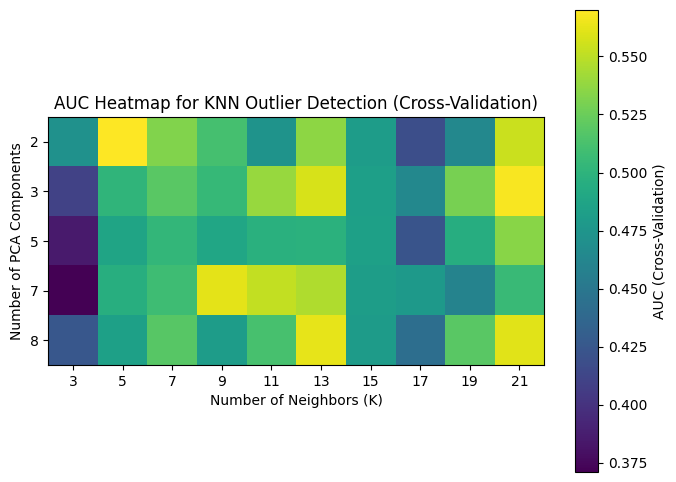

In [21]:
# KNN
# dataset: Pima_withoutdupl_norm_02_v01.csv
# stratified kfold cv
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# File path to the data
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Pima\\Pima_withoutdupl_norm_02_v01.csv"
# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate features (all columns except the last) and labels (last column)
data = df.iloc[:, :-1].values
labels = df.iloc[:, -1].values

# Dynamically calculate odd K values based on the dataset size
N_samples = len(data)  # Total number of samples
max_k = int(math.sqrt(N_samples))  # sqrt(N) for the dataset
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Total number of samples:", N_samples)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 8]  # Number of PCA components

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold stratified cross-validation
cv_results = []  # To store cross-validation results

# Perform stratified cross-validation
for n_components in n_components_values:
    for k in k_values:
        fold_aucs = []  # Store AUCs for each fold
        for train_idx, val_idx in skf.split(data, labels):
            # Split data into training and validation folds
            X_train_fold, X_val_fold = data[train_idx], data[val_idx]
            y_train_fold, y_val_fold = labels[train_idx], labels[val_idx]
            
            # Calculate KNN outlier scores on the training fold
            _, outlier_scores_fold = calculate_knn_outlier_scores(
                X_train_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation fold
            _, val_outlier_scores_fold = calculate_knn_outlier_scores(
                X_val_fold, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Compute the AUC for this fold
            _, _, auc_fold = evaluate_knn_outlier_detection(y_val_fold, _, val_outlier_scores_fold)
            fold_aucs.append(auc_fold)
        
        # Store the average AUC for this hyperparameter combination
        avg_auc = np.mean(fold_aucs)
        cv_results.append((n_components, k, avg_auc))

# Convert CV results to a structured array for analysis
cv_results = np.array(cv_results, dtype=[('n_components', int), ('k', int), ('auc', float)])

# Find the best parameters based on the maximum average AUC
best_index = np.argmax(cv_results['auc'])
best_n_components = cv_results['n_components'][best_index]
best_k = cv_results['k'][best_index]
best_auc = cv_results['auc'][best_index]

print(f"Best Hyperparameters (from Cross-Validation):")
print(f"n_components (PCA): {best_n_components}")
print(f"k (Number of Neighbors): {best_k}")
print(f"Average AUC (Cross-Validation): {best_auc}")

# Visualize the cross-validation results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        matching_auc = cv_results[(cv_results['n_components'] == n_components) & 
                                  (cv_results['k'] == k)]['auc']
        auc_matrix[i, j] = matching_auc[0] if len(matching_auc) > 0 else 0

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC (Cross-Validation)')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection (Cross-Validation)')
plt.show()
